In [7]:
import pandas as pd

import numpy as np

In [8]:
# # Number of rows
# num_rows = 1000000

# # Create sample data with 1,000,000 rows
# data = {
#     'Timestamp': pd.date_range(start='2022-01-01', periods=num_rows, freq='S'),
#     'Ticker': (['AAPL', 'GOOGL', 'MSFT', 'BTC', 'ETH', 'XRP'] * ((num_rows // 6) + 1))[:num_rows],
#     'Price': ([150, 2500, 300, 155, 2550, 310] * ((num_rows // 6) + 1))[:num_rows],
#     'Volume': ([100, 200, 150, 110, 210, 160] * ((num_rows // 6) + 1))[:num_rows],
#     'Buy/Sell': (['Buy', 'Sell', 'Buy', 'Sell', 'Buy', 'Sell'] * ((num_rows // 6) + 1))[:num_rows],
#     'Trader_ID': (['T1', 'T2', 'T3', 'T4', 'T5', 'T6'] * ((num_rows // 6) + 1))[:num_rows],
#     'Exchange': (['NYSE', 'NASDAQ', 'NYSE', 'Binance', 'Bybit', 'Coinbase'] * ((num_rows // 6) + 1))[:num_rows]
# }

# # Convert the dictionary into a DataFrame

In [9]:
exchange_df = pd.read_csv("../data/raw/Exchange_Trade_Data.csv")
exchange_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  200000 non-null  int64
 1   Timestamp   200000 non-null  str  
 2   Ticker      200000 non-null  str  
 3   Price       200000 non-null  int64
 4   Volume      200000 non-null  int64
 5   Buy/Sell    200000 non-null  str  
 6   Trader_ID   200000 non-null  str  
 7   Exchange    200000 non-null  str  
dtypes: int64(3), str(5)
memory usage: 12.2 MB


In [10]:
exchange_df.head()

,Unnamed: 0,Timestamp,Ticker,Price,Volume,Buy/Sell,Trader_ID,Exchange
0,0,2022-01-01 00:00:00,AAPL,150,100,Buy,T1,NYSE
1,1,2022-01-01 00:00:01,GOOGL,2500,200,Sell,T2,NASDAQ
2,2,2022-01-01 00:00:02,MSFT,300,150,Buy,T3,NYSE
3,3,2022-01-01 00:00:03,BTC,155,110,Sell,T4,Binance
4,4,2022-01-01 00:00:04,ETH,2550,210,Buy,T5,Bybit


In [11]:
exchange_df.shape

(200000, 8)

In [12]:
exchange_df.sample(30)

,Unnamed: 0,Timestamp,Ticker,Price,Volume,Buy/Sell,Trader_ID,Exchange
119589,119589,2022-01-02 09:13:09,BTC,155,110,Sell,T4,Binance
77477,77477,2022-01-01 21:31:17,XRP,310,160,Sell,T6,Coinbase
96297,96297,2022-01-02 02:44:57,BTC,155,110,Sell,T4,Binance
137729,137729,2022-01-02 14:15:29,XRP,310,160,Sell,T6,Coinbase
137985,137985,2022-01-02 14:19:45,BTC,155,110,Sell,T4,Binance
111990,111990,2022-01-02 07:06:30,AAPL,150,100,Buy,T1,NYSE
109615,109615,2022-01-02 06:26:55,GOOGL,2500,200,Sell,T2,NASDAQ
184787,184787,2022-01-03 03:19:47,XRP,310,160,Sell,T6,Coinbase
140791,140791,2022-01-02 15:06:31,GOOGL,2500,200,Sell,T2,NASDAQ
107309,107309,2022-01-02 05:48:29,XRP,310,160,Sell,T6,Coinbase


In [13]:
# not good way
# exchange_df.groupby('Ticker').sum()

#good way
exchange_df.groupby('Ticker')['Volume'].sum()

# or

volume_sum = {}
tickers = exchange_df['Ticker'].unique()
for ticker in tickers:
    sum_volume = exchange_df[exchange_df['Ticker'] == ticker]['Volume'].sum()
    volume_sum[ticker] = sum_volume

volume_sum

# group by is much faster than logic code

{'AAPL': np.int64(3333400),
 'GOOGL': np.int64(6666800),
 'MSFT': np.int64(4999950),
 'BTC': np.int64(3666630),
 'ETH': np.int64(6999930),
 'XRP': np.int64(5333280)}

In [14]:
# how many trades happen per stock or can say no of rows in every group
tickers = exchange_df.groupby('Ticker')
tickers.size()

Ticker
AAPL     33334
BTC      33333
ETH      33333
GOOGL    33334
MSFT     33333
XRP      33333
dtype: int64

### Group by - attributes and methods

In [15]:
#find total number of groups -> len
# find items in each group - size
# first()/last() - > nth item
# get_group vs filterring
# groups
# describe
# sample
# nunique

In [16]:
tickers
len(tickers)

6

In [17]:
# first lat row of every group
tickers.first()
tickers.last()

# 4th number of row of every group
tickers.nth(5)

,Unnamed: 0,Timestamp,Ticker,Price,Volume,Buy/Sell,Trader_ID,Exchange
30,30,2022-01-01 00:00:30,AAPL,150,100,Buy,T1,NYSE
31,31,2022-01-01 00:00:31,GOOGL,2500,200,Sell,T2,NASDAQ
32,32,2022-01-01 00:00:32,MSFT,300,150,Buy,T3,NYSE
33,33,2022-01-01 00:00:33,BTC,155,110,Sell,T4,Binance
34,34,2022-01-01 00:00:34,ETH,2550,210,Buy,T5,Bybit
35,35,2022-01-01 00:00:35,XRP,310,160,Sell,T6,Coinbase


In [18]:
# GET GROUP SEPECIFIC DATA
tickers.get_group('BTC')  # better and fast approach
#or
exchange_df[exchange_df['Ticker'] == "BTC"]

,Unnamed: 0,Timestamp,Ticker,Price,Volume,Buy/Sell,Trader_ID,Exchange
3,3,2022-01-01 00:00:03,BTC,155,110,Sell,T4,Binance
9,9,2022-01-01 00:00:09,BTC,155,110,Sell,T4,Binance
15,15,2022-01-01 00:00:15,BTC,155,110,Sell,T4,Binance
21,21,2022-01-01 00:00:21,BTC,155,110,Sell,T4,Binance
27,27,2022-01-01 00:00:27,BTC,155,110,Sell,T4,Binance
...,...,...,...,...,...,...,...,...
199971,199971,2022-01-03 07:32:51,BTC,155,110,Sell,T4,Binance
199977,199977,2022-01-03 07:32:57,BTC,155,110,Sell,T4,Binance
199983,199983,2022-01-03 07:33:03,BTC,155,110,Sell,T4,Binance
199989,199989,2022-01-03 07:33:09,BTC,155,110,Sell,T4,Binance


In [19]:
exchange_df.head(29)

,Unnamed: 0,Timestamp,Ticker,Price,Volume,Buy/Sell,Trader_ID,Exchange
0,0,2022-01-01 00:00:00,AAPL,150,100,Buy,T1,NYSE
1,1,2022-01-01 00:00:01,GOOGL,2500,200,Sell,T2,NASDAQ
2,2,2022-01-01 00:00:02,MSFT,300,150,Buy,T3,NYSE
3,3,2022-01-01 00:00:03,BTC,155,110,Sell,T4,Binance
4,4,2022-01-01 00:00:04,ETH,2550,210,Buy,T5,Bybit
5,5,2022-01-01 00:00:05,XRP,310,160,Sell,T6,Coinbase
6,6,2022-01-01 00:00:06,AAPL,150,100,Buy,T1,NYSE
7,7,2022-01-01 00:00:07,GOOGL,2500,200,Sell,T2,NASDAQ
8,8,2022-01-01 00:00:08,MSFT,300,150,Buy,T3,NYSE
9,9,2022-01-01 00:00:09,BTC,155,110,Sell,T4,Binance


In [20]:
# groups - it is an attribute of an groupby
tickers.groups

{'AAPL': [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 108, 114, 120, 126, 132, 138, 144, 150, 156, 162, 168, 174, 180, 186, 192, 198, 204, 210, 216, 222, 228, 234, 240, 246, 252, 258, 264, 270, 276, 282, 288, 294, 300, 306, 312, 318, 324, 330, 336, 342, 348, 354, 360, 366, 372, 378, 384, 390, 396, 402, 408, 414, 420, 426, 432, 438, 444, 450, 456, 462, 468, 474, 480, 486, 492, 498, 504, 510, 516, 522, 528, 534, 540, 546, 552, 558, 564, 570, 576, 582, 588, 594, ...], 'BTC': [3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81, 87, 93, 99, 105, 111, 117, 123, 129, 135, 141, 147, 153, 159, 165, 171, 177, 183, 189, 195, 201, 207, 213, 219, 225, 231, 237, 243, 249, 255, 261, 267, 273, 279, 285, 291, 297, 303, 309, 315, 321, 327, 333, 339, 345, 351, 357, 363, 369, 375, 381, 387, 393, 399, 405, 411, 417, 423, 429, 435, 441, 447, 453, 459, 465, 471, 477, 483, 489, 495, 501, 507, 513, 519, 525, 531, 537, 543, 549, 555, 561, 567, 573, 579, 585, 591, 597, ...], 'ETH': [

In [21]:
tickers.describe()

Unnamed: 0                                                            \
            count      mean           std  min      25%       50%       75%   
Ticker                                                                        
AAPL      33334.0   99999.0  57737.047638  0.0  49999.5   99999.0  149998.5   
BTC       33333.0   99999.0  57735.315588  3.0  50001.0   99999.0  149997.0   
ETH       33333.0  100000.0  57735.315588  4.0  50002.0  100000.0  149998.0   
GOOGL     33334.0  100000.0  57737.047638  1.0  50000.5  100000.0  149999.5   
MSFT      33333.0   99998.0  57735.315588  2.0  50000.0   99998.0  149996.0   
XRP       33333.0  100001.0  57735.315588  5.0  50003.0  100001.0  149999.0   

                    Price          ...                   Volume              \
             max    count    mean  ...     75%     max    count   mean  std   
Ticker                             ...                                        
AAPL    199998.0  33334.0   150.0  ...   150.0   150.0  33334.0  100.0  0.0   
BTC     199995.0  33333.0   155.0  ...   155.0   155.0  33333.0  110.0  0.0   
ETH     199996.0  33333.0  2550.0  ...  2550.0  2550.0  33333.0  210.0  0.0   
GOOGL   199999.0  33334.0  2500.0  ...  2500.0  2500.0  33334.0  200.0  0.0   
MSFT    199994.0  33333.0   300.0  ...   300.0   300.0  33333.0  150.0  0.0   
XRP     199997.0  33333.0   310.0  ...   310.0   310.0  33333.0  160.0  0.0   

                                           
          min    25%    50%    75%    max  
Ticker                                     
AAPL    100.0  100.0  100.0  100.0  100.0  
BTC     110.0  110.0  110.0  110.0  110.0  
ETH     210.0  210.0  210.0  210.0  210.0  
GOOGL   200.0  200.0  200.0  200.0  200.0  
MSFT    150.0  150.0  150.0  150.0  150.0  
XRP     160.0  160.0  160.0  160.0  160.0  

[6 rows x 24 columns]

In [22]:
# nunique - it gives no of unique value
tickers.nunique()

,Unnamed: 0,Timestamp,Price,Volume,Buy/Sell,Trader_ID,Exchange
Ticker,,,,,,,
AAPL,33334,33334,1,1,1,1,1
BTC,33333,33333,1,1,1,1,1
ETH,33333,33333,1,1,1,1,1
GOOGL,33334,33334,1,1,1,1,1
MSFT,33333,33333,1,1,1,1,1
XRP,33333,33333,1,1,1,1,1


In [23]:

 #if we pass mean() or sum() or max() it applies to all the 
# columns- result it give bad result
exchange_df.info() 
tickers[['Volume','Price']].agg(['sum','mean'])
# or - better way pass it thourgh dict

# but this we can apply to specific colum -so it gives good result
tickers.agg({
    'Volume':'sum',
    'Price':'mean',
    'Price':'min'
})

# below is the advance of passing dict and list both

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  200000 non-null  int64
 1   Timestamp   200000 non-null  str  
 2   Ticker      200000 non-null  str  
 3   Price       200000 non-null  int64
 4   Volume      200000 non-null  int64
 5   Buy/Sell    200000 non-null  str  
 6   Trader_ID   200000 non-null  str  
 7   Exchange    200000 non-null  str  
dtypes: int64(3), str(5)
memory usage: 12.2 MB


,Volume,Price
Ticker,,
AAPL,3333400,150
BTC,3666630,155
ETH,6999930,2550
GOOGL,6666800,2500
MSFT,4999950,300
XRP,5333280,310


In [24]:
tickers.agg({
    'Volume':['sum','mean','std'],
    'Price':['max','min','mean']
})

Volume             Price              
            sum   mean  std   max   min    mean
Ticker                                         
AAPL    3333400  100.0  0.0   150   150   150.0
BTC     3666630  110.0  0.0   155   155   155.0
ETH     6999930  210.0  0.0  2550  2550  2550.0
GOOGL   6666800  200.0  0.0  2500  2500  2500.0
MSFT    4999950  150.0  0.0   300   300   300.0
XRP     5333280  160.0  0.0   310   310   310.0

In [25]:
# looping in groups
tickers

In [26]:
# looping in groups
# for group, data in tickers:
#     print(group,data)
for group, data in tickers:
    print((data['Ticker'].unique()))

<StringArray>
['AAPL']
Length: 1, dtype: str
<StringArray>
['BTC']
Length: 1, dtype: str
<StringArray>
['ETH']
Length: 1, dtype: str
<StringArray>
['GOOGL']
Length: 1, dtype: str
<StringArray>
['MSFT']
Length: 1, dtype: str
<StringArray>
['XRP']
Length: 1, dtype: str


In [27]:
# apply
tickers.apply(max)

Ticker
AAPL     Volume
BTC      Volume
ETH      Volume
GOOGL    Volume
MSFT     Volume
XRP      Volume
dtype: str

In [28]:
# group by on multiple cols
exchange_df.groupby(['Ticker','Buy/Sell','Exchange']).size()

#get_group
exchange_df.groupby(['Ticker','Buy/Sell','Exchange']).get_group(('ETH','Buy','Bybit'))

tickers_exchange =exchange_df.groupby(['Ticker','Buy/Sell','Exchange'])

In [29]:
tickers_exchange.agg(['min','max'])

Unnamed: 0                    Timestamp  \
                                min     max                  min   
Ticker Buy/Sell Exchange                                           
AAPL   Buy      NYSE              0  199998  2022-01-01 00:00:00   
BTC    Sell     Binance           3  199995  2022-01-01 00:00:03   
ETH    Buy      Bybit             4  199996  2022-01-01 00:00:04   
GOOGL  Sell     NASDAQ            1  199999  2022-01-01 00:00:01   
MSFT   Buy      NYSE              2  199994  2022-01-01 00:00:02   
XRP    Sell     Coinbase          5  199997  2022-01-01 00:00:05   

                                              Price       Volume       \
                                          max   min   max    min  max   
Ticker Buy/Sell Exchange                                                
AAPL   Buy      NYSE      2022-01-03 07:33:18   150   150    100  100   
BTC    Sell     Binance   2022-01-03 07:33:15   155   155    110  110   
ETH    Buy      Bybit     2022-01-03 07:33:16  2550  2550    210  210   
GOOGL  Sell     NASDAQ    2022-01-03 07:33:19  2500  2500    200  200   
MSFT   Buy      NYSE      2022-01-03 07:33:14   300   300    150  150   
XRP    Sell     Coinbase  2022-01-03 07:33:17   310   310    160  160   

                         Trader_ID      
                               min max  
Ticker Buy/Sell Exchange                
AAPL   Buy      NYSE            T1  T1  
BTC    Sell     Binance         T4  T4  
ETH    Buy      Bybit           T5  T5  
GOOGL  Sell     NASDAQ          T2  T2  
MSFT   Buy      NYSE            T3  T3  
XRP    Sell     Coinbase        T6  T6

### Exercise

In [30]:
# How many trades were executed for each ticker?
#  tips - whenever we see each in any question we can apply groupby
exchange_df.groupby('Ticker').size()

Ticker
AAPL     33334
BTC      33333
ETH      33333
GOOGL    33334
MSFT     33333
XRP      33333
dtype: int64

In [31]:
# what is the avg price of each ticker?
exchange_df.groupby('Ticker')['Price'].mean()

Ticker
AAPL      150.0
BTC       155.0
ETH      2550.0
GOOGL    2500.0
MSFT      300.0
XRP       310.0
Name: Price, dtype: float64

In [32]:
# what is the total volume trade of each ticker?
exchange_df.groupby('Ticker')['Volume'].sum()

Ticker
AAPL     3333400
BTC      3666630
ETH      6999930
GOOGL    6666800
MSFT     4999950
XRP      5333280
Name: Volume, dtype: int64

In [33]:
# what is the price trade of each ticker?
exchange_df.groupby('Ticker')['Price'].first()

Ticker
AAPL      150
BTC       155
ETH      2550
GOOGL    2500
MSFT      300
XRP       310
Name: Price, dtype: int64

In [34]:
exchange_df.groupby('Ticker')['Price'].last()

Ticker
AAPL      150
BTC       155
ETH      2550
GOOGL    2500
MSFT      300
XRP       310
Name: Price, dtype: int64

In [35]:
# what is the total trade volume on each exchange for each hour of the day?
exchange_df['Hour'] = pd.to_datetime(exchange_df['Timestamp']).dt.hour
exchange_df.groupby(['Volume','Hour'])['Volume'].sum()

Volume  Hour
100     0       180000
        1       180000
        2       180000
        3       180000
        4       180000
                 ...  
210     19      252000
        20      252000
        21      252000
        22      252000
        23      252000
Name: Volume, Length: 144, dtype: int64

In [36]:
# what is the total buy and sell volume of each ticker?
buy_volume = exchange_df[exchange_df['Buy/Sell'] == 'Buy'].groupby('Ticker')['Volume'].sum()
sell_volume = exchange_df[exchange_df['Buy/Sell'] == 'Sell'].groupby('Ticker')['Volume'].sum()


VWAP formula-
VWAP (Volume Weighted Average Price) ka use trading mein bahut important hai. Simple moving average sirf price dekhta hai, lekin VWAP price + volume dono ko weight deta hai.

Jis price pe zyada volume trade hua,
uska importance zyada hoga.

Use case:
Buy decision
Current Price > VWAP

Matlab stock VWAP ke upar trade kar raha hai → bullish signal consider kar sakte hain.
--------------------------------------

Sell decision
Current Price < VWAP

Example:

Current Price = 95
VWAP = 110

Interpretation:

Stock average traded level se neeche hai
Weakness ho sakti hai

In [ ]:
# # e.g
# Price   Volume
# 100      10
# 110      20
# 120      30
# ((100*10) + (110*20) + (120*30)) / (10+20+30)

# = (1000 + 2200 + 3600) / 60

# = 6800 / 60

# = 113.33

In [37]:
# calculate the VWAP for each ticker?

exchange_df.groupby('Ticker').apply(lambda x : (x['Volume'] * x['Price']).sum()/x['Volume'].sum())

Ticker
AAPL      150.0
BTC       155.0
ETH      2550.0
GOOGL    2500.0
MSFT      300.0
XRP       310.0
dtype: float64

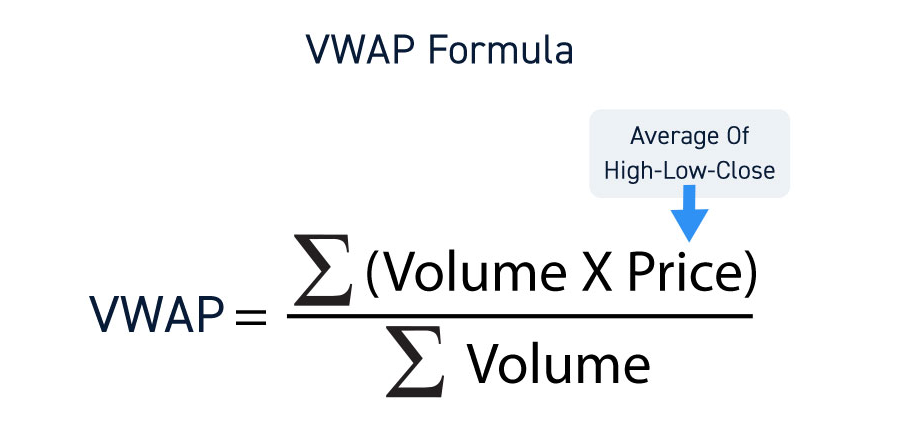